In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q transformers>=4.38.2 torch torchvision

In [4]:
import torch
print(f"CUDA: {torch.cuda.is_available()}")
print(f"GPU : {torch.cuda.get_device_name(0)}")

CUDA: True
GPU : NVIDIA L4


In [5]:
import os, json, re, warnings
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import torch
import torchvision
from PIL import Image
from tqdm import tqdm
from transformers import Owlv2Processor, Owlv2ForObjectDetection
from sklearn.metrics import roc_auc_score, average_precision_score

# ═══════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════
EVAL_JSON      = "/content/drive/MyDrive/AIP491/output/dataset_eval.json"
OUTPUT_DIR     = "/content/drive/MyDrive/AIP491/results/owlvit_base"
MODEL_NAME     = "google/owlv2-base-patch16-ensemble"
SCORE_THRESHOLD = 0.17
IOU_THRESHOLD   = 0.50
NMS_THRESHOLD   = 0.50
GENERIC_PROMPT  = ["defect", "anomaly", "damage", "scratch", "crack", "contamination"]
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"

# ═══════════════════════════════════════════════════════
# QUERY BUILDER
# ═══════════════════════════════════════════════════════
def build_query(sample: dict) -> str:
    """
    Format: "category defect_type location"
    """
    category    = sample["category"].replace("_", " ")
    defect_type = sample["defect_type"].replace("_", " ")
    location    = sample.get("location", "").replace("-", " ").replace("_", " ")

    parts = [category, defect_type]
    if location and location.lower() not in ("none", "unknown", ""):
        parts.append(location)

    return " ".join(parts)

# Ví dụ output:
# "bottle broken large top left"
# "cable missing cable center"
# "pill scratch top center"

# ═══════════════════════════════════════════════════════
# DATA LOADING
# ═══════════════════════════════════════════════════════
def load_eval_dataset(path: str):
    with open(path) as f:
        data = json.load(f)

    defect = [
        s for s in data
        if s.get("defect_type") != "good"
        and s.get("bboxes")
        and s.get("mask_path")
        and s.get("generated_text")
        and os.path.exists(s["original_path"])
    ]
    good = [
        s for s in data
        if (s.get("defect_type") == "good" or s.get("split") == "test_good")
        and os.path.exists(s["original_path"])
    ]

    print(f"Eval set loaded:")
    print(f"  Defect : {len(defect):,}")
    print(f"  Good   : {len(good):,}")
    for src in ["mvtec", "visa"]:
        d = sum(1 for s in defect if s["dataset_source"] == src)
        g = sum(1 for s in good   if s["dataset_source"] == src)
        print(f"  {src.upper():<8} defect={d:,} | good={g:,}")

    return defect, good


# ═══════════════════════════════════════════════════════
# MODEL LOADING
# ═══════════════════════════════════════════════════════
def load_owlvit():
    print(f"\nLoading OWL-ViT v2 ({MODEL_NAME}) on {DEVICE}...")
    processor = Owlv2Processor.from_pretrained(MODEL_NAME)
    model     = Owlv2ForObjectDetection.from_pretrained(MODEL_NAME)
    model.to(DEVICE).eval()
    print("Ready.\n")
    return processor, model


# ═══════════════════════════════════════════════════════
# INFERENCE
# ═══════════════════════════════════════════════════════
def apply_nms(bboxes: list, scores: list) -> tuple:
    if not bboxes:
        return [], []
    keep = torchvision.ops.nms(
        torch.tensor(bboxes,  dtype=torch.float32),
        torch.tensor(scores,  dtype=torch.float32),
        NMS_THRESHOLD,
    )
    return ([bboxes[i] for i in keep.tolist()],
            [scores[i] for i in keep.tolist()])


def run_inference(processor, model, img_path: str,
                  text_queries: list) -> tuple:
    """
    Returns pred_bboxes [[x1,y1,x2,y2],...], pred_scores [float,...], (h,w)
    text_queries: list of str — OWL-ViT accepts multiple queries per image
    """
    image    = Image.open(img_path).convert("RGB")
    w, h     = image.size

    inputs   = processor(
        text=[text_queries], images=image, return_tensors="pt"
    )
    inputs   = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    # Manual post-process — no dependency on processor/model method
    logits     = outputs.logits[0]      # (num_queries, num_text)
    pred_boxes = outputs.pred_boxes[0]  # (num_queries, 4) normalized cxcywh

    scores = torch.sigmoid(logits).max(dim=-1).values
    keep   = scores >= SCORE_THRESHOLD
    scores     = scores[keep].cpu().numpy().tolist()
    pred_boxes = pred_boxes[keep].cpu()

    if len(scores) == 0:
        return [], [], (h, w)

    # Convert normalized cxcywh → absolute xyxy using original w, h
    cx, cy = pred_boxes[:, 0], pred_boxes[:, 1]
    bw, bh = pred_boxes[:, 2], pred_boxes[:, 3]
    x1 = ((cx - bw / 2) * w).numpy().tolist()
    y1 = ((cy - bh / 2) * h).numpy().tolist()
    x2 = ((cx + bw / 2) * w).numpy().tolist()
    y2 = ((cy + bh / 2) * h).numpy().tolist()

    boxes = [
        [max(0.0, x1[i]), max(0.0, y1[i]),
         min(float(w), x2[i]), min(float(h), y2[i])]
        for i in range(len(scores))
    ]

    boxes, scores = apply_nms(boxes, scores)
    return boxes, scores, (h, w)


# ═══════════════════════════════════════════════════════
# METRIC HELPERS
# ═══════════════════════════════════════════════════════
def mask_to_binary(mask_path: str, img_hw: tuple) -> np.ndarray:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return np.zeros(img_hw, dtype=np.uint8)
    h, w = img_hw
    if mask.shape != (h, w):
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
    _, binary = cv2.threshold(mask, 0, 1, cv2.THRESH_BINARY)
    return binary.astype(np.uint8)


def bboxes_to_map(bboxes: list, img_hw: tuple) -> np.ndarray:
    h, w = img_hw
    pmap = np.zeros((h, w), dtype=np.float32)
    for x1, y1, x2, y2 in bboxes:
        x1, y1 = max(0, int(x1)), max(0, int(y1))
        x2, y2 = min(w, int(x2)), min(h, int(y2))
        if x2 > x1 and y2 > y1:
            pmap[y1:y2, x1:x2] = 1.0
    return pmap


def compute_iou(a: list, b: list) -> float:
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])
    inter  = max(0, xB - xA) * max(0, yB - yA)
    union  = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / union if union > 0 else 0.0


def save_viz(img_path, pred_bboxes, gt_bboxes, save_path):
    img = cv2.imread(img_path)
    if img is None:
        return
    for b in gt_bboxes:
        x1, y1, x2, y2 = [int(v) for v in b]
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(img, "GT", (x1, max(0, y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
    for b in pred_bboxes:
        x1, y1, x2, y2 = [int(v) for v in b]
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, "PRED", (x1, max(0, y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    cv2.imwrite(save_path, img)


# ═══════════════════════════════════════════════════════
# METRICS
# ═══════════════════════════════════════════════════════
def auroc_image(sd: list, sg: list) -> float:
    y = [1]*len(sd) + [0]*len(sg)
    s = list(sd) + list(sg)
    return float(roc_auc_score(y, s)) if len(set(y)) == 2 else float("nan")


def auroc_pixel(pmaps: list, gmasks: list) -> float:
    p = np.concatenate([m.flatten() for m in pmaps])
    g = np.concatenate([m.flatten() for m in gmasks])
    return float(roc_auc_score(g, p)) if g.sum() > 0 else float("nan")


def pr_auc(sd: list, sg: list) -> float:
    y = [1]*len(sd) + [0]*len(sg)
    s = list(sd) + list(sg)
    return float(average_precision_score(y, s)) if len(set(y)) == 2 else float("nan")


def map_50(pred_boxes: list, gt_boxes: list, pred_scores: list) -> float:
    tp, fp, sc = [], [], []
    n_gt = sum(len(g) for g in gt_boxes)
    for pbs, gbs, pss in zip(pred_boxes, gt_boxes, pred_scores):
        matched = set()
        for pb, ps in sorted(zip(pbs, pss), key=lambda x: -x[1]):
            best_iou, best_j = 0.0, -1
            for j, gb in enumerate(gbs):
                if j in matched:
                    continue
                v = compute_iou(pb, gb)
                if v > best_iou:
                    best_iou, best_j = v, j
            sc.append(ps)
            if best_iou >= IOU_THRESHOLD and best_j >= 0:
                tp.append(1); fp.append(0); matched.add(best_j)
            else:
                tp.append(0); fp.append(1)
    if not sc or n_gt == 0:
        return float("nan")
    idx  = np.argsort(sc)[::-1]
    tpc  = np.cumsum(np.array(tp)[idx])
    fpc  = np.cumsum(np.array(fp)[idx])
    prec = tpc / (tpc + fpc + 1e-9)
    rec  = tpc / (n_gt + 1e-9)
    rec  = np.concatenate([[0], rec,  [rec[-1]]])
    prec = np.concatenate([[1], prec, [0]])
    return float(np.trapz(prec, rec))


# ═══════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════
def main():
    print(f"Device : {DEVICE}")
    print(f"Model  : {MODEL_NAME}")
    print(f"Config : SCORE_THR={SCORE_THRESHOLD} | "
          f"NMS={NMS_THRESHOLD} | IOU={IOU_THRESHOLD}\n")

    defect_samples, good_samples = load_eval_dataset(EVAL_JSON)
    processor, model             = load_owlvit()

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    viz_dir = os.path.join(OUTPUT_DIR, "visualizations")

    # Accumulators — global
    g_sd, g_sg       = [], []
    g_pm, g_gm       = [], []
    g_pb, g_gb, g_ps = [], [], []

    # Accumulators — per category
    c_sd = defaultdict(list); c_sg = defaultdict(list)
    c_pb = defaultdict(list); c_gb = defaultdict(list)
    c_ps = defaultdict(list)
    c_pm = defaultdict(list); c_gm = defaultdict(list)

    raw_scores = []
    n_viz      = 0

    # STEP 1: Defective samples
    print("=" * 52)
    print("STEP 1/3  Defective samples")
    print("=" * 52)

    for s in tqdm(defect_samples, desc="Defective"):
        img_path  = s["original_path"]
        mask_path = s["mask_path"]
        gt_bboxes = s["bboxes"]
        cat       = s["category"]
        query     = build_query(s)

        try:
            pred_bboxes, pred_scores, (h, w) = run_inference(
                processor, model, img_path, [query])
        except Exception as e:
            tqdm.write(f"[ERR] {Path(img_path).name}: {e}")
            pred_bboxes, pred_scores = [], []
            img = cv2.imread(img_path)
            h, w = img.shape[:2] if img is not None else (256, 256)

        score = float(max(pred_scores)) if pred_scores else 0.0
        pmap  = bboxes_to_map(pred_bboxes, (h, w))
        gmask = mask_to_binary(mask_path, (h, w))

        # Global
        g_sd.append(score)
        g_pm.append(pmap);        g_gm.append(gmask)
        g_pb.append(pred_bboxes); g_gb.append(gt_bboxes)
        g_ps.append(pred_scores if pred_scores else [0.0])

        # Per-category
        c_sd[cat].append(score)
        c_pb[cat].append(pred_bboxes); c_gb[cat].append(gt_bboxes)
        c_ps[cat].append(pred_scores if pred_scores else [0.0])
        c_pm[cat].append(pmap);        c_gm[cat].append(gmask)

        # Raw scores (for ROC curve)
        raw_scores.append({
            "label"       : 1,
            "score"       : score,
            "category"    : cat,
            "defect_type" : s["defect_type"],
            "dataset"     : s["dataset_source"],
            "query"       : query,
            "n_pred_boxes": len(pred_bboxes),
        })

        # Save first 150 visualizations
        if n_viz < 150 and pred_bboxes:
            save_viz(
                img_path, pred_bboxes, gt_bboxes,
                os.path.join(viz_dir,
                    f"{s['dataset_source']}_{cat}_"
                    f"{s['defect_type']}_{Path(img_path).stem}.jpg")
            )
            n_viz += 1

    # STEP 2: Normal / Good samples
    print(f"\n{'='*52}")
    print("STEP 2/3  Normal samples  (image-level AUROC)")
    print(f"{'='*52}")

    for s in tqdm(good_samples, desc="Normal"):
        cat = s["category"]
        try:
            _, pred_scores, _ = run_inference(
                processor, model,
                s["original_path"],
                GENERIC_PROMPT,         # list of 6 generic defect keywords
            )
            score = float(max(pred_scores)) if pred_scores else 0.0
        except Exception:
            score = 0.0

        g_sg.append(score)
        c_sg[cat].append(score)
        raw_scores.append({
            "label"       : 0,
            "score"       : score,
            "category"    : cat,
            "defect_type" : "good",
            "dataset"     : s["dataset_source"],
            "query"       : str(GENERIC_PROMPT),
            "n_pred_boxes": 0,
        })

    # STEP 3: Compute metrics
    print(f"\n{'='*52}")
    print("STEP 3/3  Computing metrics")
    print(f"{'='*52}\n")

    res = {
        "AUROC_image"    : auroc_image(g_sd, g_sg),
        "AUROC_pixel"    : auroc_pixel(g_pm, g_gm),
        "PR_AUC"         : pr_auc(g_sd, g_sg),
        "mAP@0.5"        : map_50(g_pb, g_gb, g_ps),
    }

    per_cat = {
        cat: {
            "AUROC_image": auroc_image(c_sd[cat], c_sg.get(cat, [])),
            "AUROC_pixel": auroc_pixel(c_pm[cat], c_gm[cat]),
            "mAP@0.5"    : map_50(c_pb[cat], c_gb[cat], c_ps[cat]),
            "n_defect"   : len(c_sd[cat]),
            "n_good"     : len(c_sg.get(cat, [])),
        }
        for cat in sorted(c_sd.keys())
    }

    # Print results
    def fv(v):
        return f"{v:.4f}" if isinstance(v, float) and not np.isnan(v) else "N/A"

    SEP = "=" * 54
    print(SEP)
    print("  OWL-ViT v2 Base — concat mode (category + defect_type)")
    print(SEP)
    print(f"  SCORE_THR={SCORE_THRESHOLD} | NMS={NMS_THRESHOLD} | IOU={IOU_THRESHOLD}")
    print(f"  Defect={len(defect_samples):,} | Good={len(good_samples):,}")
    print(f"\n  {'AUROC (Image-level)':<26} {fv(res['AUROC_image'])}")
    print(f"  {'AUROC (Pixel-level)':<26} {fv(res['AUROC_pixel'])}")
    print(f"  {'PR AUC':<26} {fv(res['PR_AUC'])}")
    print(f"  {'mAP@0.5':<26} {fv(res['mAP@0.5'])}")
    print(SEP)
    print(f"\n  {'Category':<22} {'n_def':>5} {'AUROC_img':>10} "
          f"{'AUROC_px':>10} {'mAP@0.5':>10}")
    print(f"  {'-'*59}")
    for cat, m in sorted(per_cat.items()):
        print(f"  {cat:<22} {m['n_defect']:>5} "
              f"{fv(m['AUROC_image']):>10} "
              f"{fv(m['AUROC_pixel']):>10} "
              f"{fv(m['mAP@0.5']):>10}")

    # Save results
    out_json = os.path.join(OUTPUT_DIR, "owlvit_base_results.json")
    with open(out_json, "w") as f:
        json.dump({
            "model"          : "OWL-ViT-v2-Base",
            "score_threshold": SCORE_THRESHOLD,
            "nms_threshold"  : NMS_THRESHOLD,
            "iou_threshold"  : IOU_THRESHOLD,
            "n_defect"       : len(defect_samples),
            "n_good"         : len(good_samples),
            "global_metrics" : {
                k: (None if isinstance(v, float) and np.isnan(v)
                    else round(v, 6))
                for k, v in res.items()
            },
            "per_category"   : {
                cat: {
                    mk: (None if isinstance(mv, float) and np.isnan(mv)
                         else (round(mv, 6) if isinstance(mv, float) else mv))
                    for mk, mv in m.items()
                }
                for cat, m in per_cat.items()
            },
        }, f, indent=2, default=str)

    raw_json = os.path.join(OUTPUT_DIR, "owlvit_base_raw_scores.json")
    with open(raw_json, "w") as f:
        json.dump(raw_scores, f, indent=2, default=str)

    print(f"\n  Results    -> {out_json}")
    print(f"  Raw scores -> {raw_json}")
    print(f"  Visuals    -> {viz_dir}/ ({n_viz} images)\n")

    return res, raw_scores

In [6]:
results, raw_scores = main()

Device : cuda
Model  : google/owlv2-base-patch16-ensemble
Config : SCORE_THR=0.17 | NMS=0.5 | IOU=0.5

Eval set loaded:
  Defect : 304
  Good   : 2,000
  MVTEC    defect=184 | good=395
  VISA     defect=120 | good=1,605

Loading OWL-ViT v2 (google/owlv2-base-patch16-ensemble) on cuda...


preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

The image processor of type `Owlv2ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Ready.

STEP 1/3  Defective samples


Defective: 100%|██████████| 304/304 [14:42<00:00,  2.90s/it]



STEP 2/3  Normal samples  (image-level AUROC)


Normal: 100%|██████████| 2000/2000 [48:22<00:00,  1.45s/it]



STEP 3/3  Computing metrics

  OWL-ViT v2 Base — concat mode (category + defect_type)
  SCORE_THR=0.17 | NMS=0.5 | IOU=0.5
  Defect=304 | Good=2,000

  AUROC (Image-level)        0.6430
  AUROC (Pixel-level)        0.5616
  PR AUC                     0.2429
  mAP@0.5                    0.0045

  Category               n_def  AUROC_img   AUROC_px    mAP@0.5
  -----------------------------------------------------------
  bottle                     8     0.3214     0.5000        N/A
  cable                     13     0.4688     0.5000        N/A
  candle                    10     1.0000     0.6476     0.0000
  capsule                   14     0.4660     0.5055     0.0714
  capsules                  10     0.9932     0.7463     0.0000
  carpet                    15     0.9253     0.4718     0.0014
  cashew                    10     1.0000     0.8674     0.0000
  chewinggum                10     0.4886     0.5000        N/A
  fryum                     10     0.6370     0.7820     0.1867
  

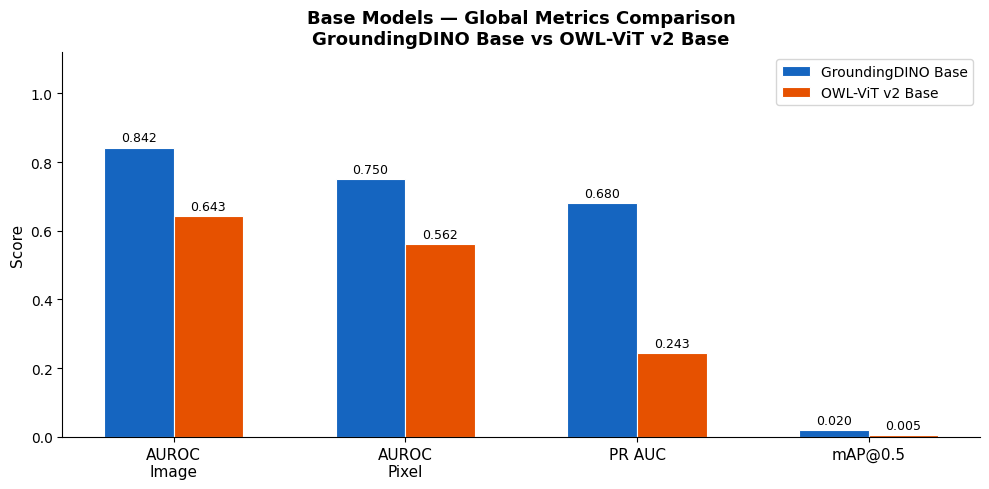

Saved: plot_base_comparison.png


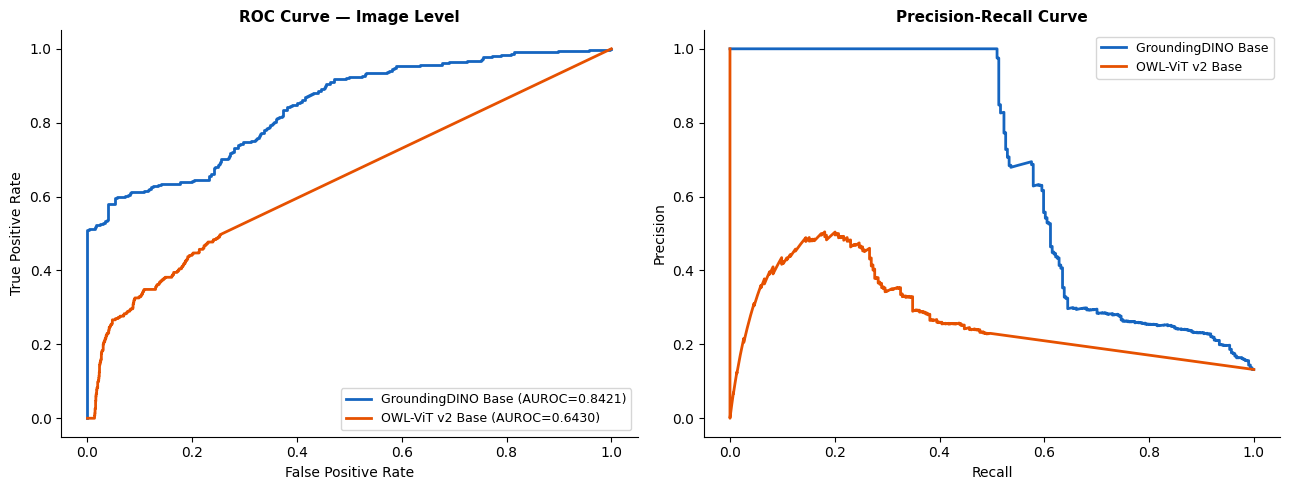

Saved: plot_roc_pr_comparison.png


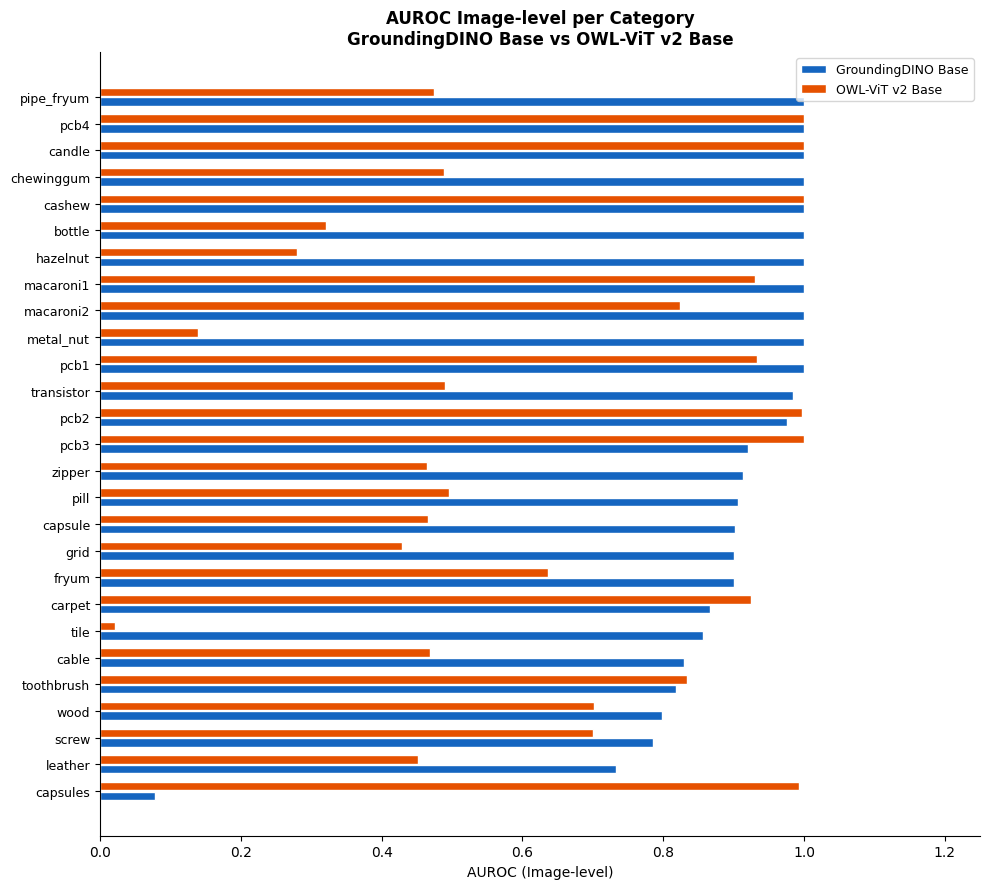

Saved: plot_per_cat_auroc.png

  FINAL SUMMARY — Base Models
  Model                       AUROC_img   AUROC_px   PR_AUC   mAP@0.5
  --------------------------------------------------------------
  GroundingDINO Base             0.8421     0.7496   0.6800    0.0195
  OWL-ViT v2 Base                0.6430     0.5616   0.2429    0.0045


In [7]:
import json, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

OUTPUT_BASE = "/content/drive/MyDrive/AIP491/results"

# Load results
with open(f"{OUTPUT_BASE}/gd_base/gd_base_results.json") as f: gd_res  = json.load(f)
with open(f"{OUTPUT_BASE}/gd_base/gd_base_raw_scores.json") as f: gd_raw  = json.load(f)
with open(f"{OUTPUT_BASE}/owlvit_base/owlvit_base_results.json") as f: owl_res = json.load(f)
with open(f"{OUTPUT_BASE}/owlvit_base/owlvit_base_raw_scores.json") as f: owl_raw = json.load(f)

def safe(d, k):
    v = d["global_metrics"].get(k)
    return v if v is not None else float("nan")

def get_cat(d, cat, metric):
    v = d["per_category"].get(cat, {}).get(metric)
    return v if v is not None else 0.0

# ══════════════════════════════════════════════════════════════════
# PLOT 1 — Global metrics comparison
# ══════════════════════════════════════════════════════════════════
metrics = ["AUROC_image", "AUROC_pixel", "PR_AUC", "mAP@0.5"]
metric_labels = ["AUROC\nImage", "AUROC\nPixel", "PR AUC", "mAP@0.5"]
models_plot = {
    "GroundingDINO Base"   : (gd_res,  "#1565C0"),
    "OWL-ViT v2 Base"     : (owl_res, "#E65100"),
}

x, width = np.arange(len(metrics)), 0.30
fig, ax  = plt.subplots(figsize=(10, 5))

for i, (name, (data, color)) in enumerate(models_plot.items()):
    vals = [safe(data, m) for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color, edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width/2)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Base Models — Global Metrics Comparison\n"
             "GroundingDINO Base vs OWL-ViT v2 Base",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_BASE}/plot_base_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_base_comparison.png")

# ══════════════════════════════════════════════════════════════════
# PLOT 2 — ROC + PR curves
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, raw, color in [
    ("GroundingDINO Base", gd_raw,  "#1565C0"),
    ("OWL-ViT v2 Base",    owl_raw, "#E65100"),
]:
    ys = [r["label"] for r in raw]
    ss = [r["score"] for r in raw]
    fpr, tpr, _ = roc_curve(ys, ss)
    auroc = float(np.trapz(tpr, fpr))
    axes[0].plot(fpr, tpr, color=color, lw=2,
                  label=f"{name} (AUROC={auroc:.4f})")
    prec, rec, _ = precision_recall_curve(ys, ss)
    axes[1].plot(rec, prec, color=color, lw=2, label=name)

pos_rate = sum(1 for r in owl_raw if r["label"] == 1) / len(owl_raw)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Image Level", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_BASE}/plot_roc_pr_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_roc_pr_comparison.png")

# ══════════════════════════════════════════════════════════════════
# PLOT 3 — Per-category AUROC Image-level
# ══════════════════════════════════════════════════════════════════
cats    = sorted(set(gd_res["per_category"]) & set(owl_res["per_category"]))
gd_vals  = [get_cat(gd_res,  c, "AUROC_image") for c in cats]
owl_vals = [get_cat(owl_res, c, "AUROC_image") for c in cats]
idx     = np.argsort(gd_vals)
cats_s  = [cats[i]    for i in idx]
gd_s    = [gd_vals[i] for i in idx]
owl_s   = [owl_vals[i] for i in idx]

fig, ax = plt.subplots(figsize=(10, 9))
y = np.arange(len(cats_s))
ax.barh(y - 0.18, gd_s,  0.32, label="GroundingDINO Base",
         color="#1565C0", edgecolor="white")
ax.barh(y + 0.18, owl_s, 0.32, label="OWL-ViT v2 Base",
         color="#E65100", edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(cats_s, fontsize=9)
ax.set_xlim(0, 1.25)
ax.set_xlabel("AUROC (Image-level)", fontsize=10)
ax.set_title("AUROC Image-level per Category\n"
             "GroundingDINO Base vs OWL-ViT v2 Base",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_BASE}/plot_per_cat_auroc.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_per_cat_auroc.png")

# ══════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════
def fv(v):
    return f"{v:.4f}" if isinstance(v, float) and not np.isnan(v) else "N/A"

SEP = "=" * 62
print(f"\n{SEP}")
print("  FINAL SUMMARY — Base Models")
print(SEP)
print(f"  {'Model':<26} {'AUROC_img':>10} {'AUROC_px':>10} "
      f"{'PR_AUC':>8} {'mAP@0.5':>9}")
print(f"  {'-'*62}")
for name, d in [("GroundingDINO Base", gd_res), ("OWL-ViT v2 Base", owl_res)]:
    print(f"  {name:<26} "
          f"{fv(safe(d,'AUROC_image')):>10} "
          f"{fv(safe(d,'AUROC_pixel')):>10} "
          f"{fv(safe(d,'PR_AUC')):>8} "
          f"{fv(safe(d,'mAP@0.5')):>9}")
print(SEP)